# Low-Data Hybrid DR Training: Residual Mixing + Conflict Brake + Distillation + BiGRU

Bu notebook az veri senaryosu icin agresif olmayan ama etkili deney setini kurar.

Deney paketi (orijinal veri, 80-10-10 split):
- Teacher agir CNN+ViT + Student hafif CNN+ViT (Base Residual Logit Mixing)
- Ayni yapi + catisma freni (conflict brake)
- Ayni yapi + ordinal ceza + multi-temperature distillation
- Ayni yapi + Token-BiGRU (hafif) + ordinal/distill
- Teacher agir CNN+ViT + Student ConvNeXt-Tiny (residual mix)
- Teacher agir CNN+ViT + Student EfficientNet-B0 (residual mix)
- Screening sonrasi en iyi 2 modeli 3 seed ile finalize etme

Temel hedefler:
- Checkpoint ile kopma sonrasi egitime devam (resume-safe)
- Test set uzerinde tum basari metriklerini hesaplama
- En iyi modeli kaydetme
- Parametre sayisi ve inference hizi raporlama
- Ranking, egitim egrileri ve confusion matrix gorselleri

In [1]:
# 1) Imports
import os
import sys
import json
import time
import random
import warnings
from pathlib import Path
from typing import Dict, Tuple, List, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.models import efficientnet_b0, convnext_tiny

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Libraries imported
PyTorch: 2.9.1+cu126
CUDA available: True
GPU: NVIDIA RTX A5000


In [2]:
# 2) Setup and Module Imports
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
results_dir = Path('results/lowdata_hybrid_distill')
results_dir.mkdir(parents=True, exist_ok=True)

required_files = [
    'models/hybrid_cnn_vit_base.py',
    'models/advanced_hybrid_models.py',
    'advanced_model_configs.py',
    'model_configs.py',
    'dataset_loader.py'
 ]
for f in required_files:
    if not Path(f).exists():
        raise FileNotFoundError(f'Missing required file: {f}')

import importlib
for m in [
    'models.hybrid_cnn_vit_base',
    'models.advanced_hybrid_models',
    'advanced_model_configs',
    'dataset_loader',
    'model_configs'
 ]:
    if m in sys.modules:
        importlib.reload(sys.modules[m])

from models.hybrid_cnn_vit_base import HybridCNNViTBase
from models.advanced_hybrid_models import AdvancedHybridModel
from advanced_model_configs import get_advanced_model_config
from dataset_loader import get_data_loaders

print('Device:', device)
print('Results dir:', results_dir)

Device: cuda
Results dir: results\lowdata_hybrid_distill


In [3]:
# 3) Load Data (80-10-10)
batch_size = 16
train_loader, val_loader, test_loader, class_weights, split_data = get_data_loaders(
    dataset_path='APTOS2019',
    batch_size=batch_size
)

X_train, y_train, X_val, y_val, X_test, y_test = split_data
total = len(X_train) + len(X_val) + len(X_test)

print('Dataset loaded')
print(f'Train: {len(X_train)} ({len(X_train)/total*100:.1f}%)')
print(f'Val:   {len(X_val)} ({len(X_val)/total*100:.1f}%)')
print(f'Test:  {len(X_test)} ({len(X_test)/total*100:.1f}%)')
print('Class weights:', class_weights)

Total training samples: 3662
Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

--- Öngörülen Veri Dağılımı ---
Eğitim (Train) : ~2929 örnek (%80.0)
Doğrulama (Val): ~366 örnek (%10.0)
Test (Test)    : ~366 örnek (%10.0)
-------------------------------
Resimler diske yüklenmeye başlıyor, lütfen bekleyin...

Loaded 100/3662 images
Loaded 200/3662 images
Loaded 300/3662 images
Loaded 400/3662 images
Loaded 500/3662 images
Loaded 600/3662 images
Loaded 700/3662 images
Loaded 800/3662 images
Loaded 900/3662 images
Loaded 1000/3662 images
Loaded 1100/3662 images
Loaded 1200/3662 images
Loaded 1300/3662 images
Loaded 1400/3662 images
Loaded 1500/3662 images
Loaded 1600/3662 images
Loaded 1700/3662 images
Loaded 1800/3662 images
Loaded 1900/3662 images
Loaded 2000/3662 images
Loaded 2100/3662 images
Loaded 2200/3662 images
Loaded 2300/3662 images
Loaded 2400/3662 images
Loaded 2500/3662 images
Loaded 2600/3662 images
Loaded 2700/3662 ima

In [4]:
# 4) Metric Helpers
def _mean_specificity(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        denom = tn + fp
        specs.append((tn / denom) if denom > 0 else 0.0)
    return float(np.mean(specs))

def compute_full_metrics(y_true, y_pred, y_prob, num_classes=5):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    metrics = {}
    metrics['accuracy'] = float(accuracy_score(y_true, y_pred))
    metrics['precision_macro'] = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['recall_macro'] = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['f1_macro'] = float(f1_score(y_true, y_pred, average='macro', zero_division=0))
    metrics['precision_weighted'] = float(precision_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['recall_weighted'] = float(recall_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['f1_weighted'] = float(f1_score(y_true, y_pred, average='weighted', zero_division=0))
    metrics['specificity'] = _mean_specificity(y_true, y_pred, num_classes=num_classes)
    metrics['qwk'] = float(cohen_kappa_score(y_true, y_pred, weights='quadratic'))

    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))
    except Exception:
        metrics['roc_auc'] = 0.0

    return metrics

def class_weight_tensor_from_dict(class_weights_dict, device, n_classes=5):
    if isinstance(class_weights_dict, dict):
        arr = [float(class_weights_dict.get(i, 1.0)) for i in range(n_classes)]
    else:
        arr = [1.0] * n_classes
    return torch.tensor(arr, dtype=torch.float32, device=device)

print('Metric helpers ready')

Metric helpers ready


In [5]:
# 5) Models: Residual Teacher-Student Variants + Token-BiGRU
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def count_model_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(total), int(trainable), int(total - trainable)


class LiteCNNViTStudent(nn.Module):
    """Low-parameter CNN+ViT student for low-data setup."""
    def __init__(self, num_classes: int = 5, embed_dim: int = 128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=16, stride=16)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.vit_encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.vit_fc = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        self.fusion = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        tokens = self.patch_embed(x).flatten(2).transpose(1, 2)  # (B, N, C)
        tokens = self.vit_encoder(tokens)
        vit_feat = self.vit_fc(tokens.mean(dim=1))
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        logits = self.fusion(fused)
        return logits, {'student_feat': fused}


class LiteCNNViTBiGRUStudent(nn.Module):
    """Token-aware lightweight student: ViT tokens -> BiGRU summary."""
    def __init__(self, num_classes: int = 5, embed_dim: int = 128, gru_hidden: int = 96):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
        )

        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=16, stride=16)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )
        self.vit_encoder = nn.TransformerEncoder(enc_layer, num_layers=1)
        self.bigru = nn.GRU(
            input_size=embed_dim,
            hidden_size=gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fusion = nn.Sequential(
            nn.Linear(128 + 2 * gru_hidden, 160),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(160, num_classes),
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        tokens = self.patch_embed(x).flatten(2).transpose(1, 2)
        tokens = self.vit_encoder(tokens)
        seq, _ = self.bigru(tokens)
        token_feat = seq.mean(dim=1)
        fused = torch.cat([cnn_feat, token_feat], dim=1)
        logits = self.fusion(fused)
        return logits, {'student_feat': fused}


class EfficientNetB0Student(nn.Module):
    def __init__(self, num_classes: int = 5):
        super().__init__()
        try:
            from torchvision.models import EfficientNet_B0_Weights
            self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        except Exception:
            self.backbone = efficientnet_b0(weights=None)
        in_feat = self.backbone.classifier[-1].in_features
        self.backbone.classifier[-1] = nn.Linear(in_feat, num_classes)

    def forward(self, x):
        logits = self.backbone(x)
        return logits, {}


class ConvNeXtTinyStudent(nn.Module):
    def __init__(self, num_classes: int = 5):
        super().__init__()
        try:
            from torchvision.models import ConvNeXt_Tiny_Weights
            self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        except Exception:
            self.backbone = convnext_tiny(weights=None)
        in_feat = self.backbone.classifier[-1].in_features
        self.backbone.classifier[-1] = nn.Linear(in_feat, num_classes)

    def forward(self, x):
        logits = self.backbone(x)
        return logits, {}


class HeavyTeacherEnsemble(nn.Module):
    """Teacher architecture must match the previously trained improved anchored model."""
    def __init__(self, baseline_model: nn.Module, adv_model: nn.Module):
        super().__init__()
        self.baseline_model = baseline_model
        self.adv_model = adv_model
        for p in self.baseline_model.parameters():
            p.requires_grad = False
        self.gate = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _entropy(p: torch.Tensor) -> torch.Tensor:
        p = p.clamp_min(1e-8)
        return -(p * torch.log(p)).sum(dim=1, keepdim=True)

    def forward(self, x):
        with torch.no_grad():
            base_logits = self.baseline_model(x)
            p_base = F.softmax(base_logits, dim=1)

        adv_logits, _ = self.adv_model(x)
        p_adv = F.softmax(adv_logits, dim=1)

        ent_base = self._entropy(p_base)
        ent_adv = self._entropy(p_adv)
        conf_gap = (p_base.max(dim=1, keepdim=True).values - p_adv.max(dim=1, keepdim=True).values).abs()
        g_in = torch.cat([p_base, p_adv, ent_base, ent_adv, conf_gap], dim=1)
        g = self.gate(g_in)

        p_final = (1.0 - g) * p_base + g * p_adv
        z_teacher = torch.log(p_final.clamp_min(1e-8))
        return z_teacher, {'gate': g, 'p_teacher': p_final}


def load_frozen_baseline_model(baseline_ckpt: Path, baseline_config: Dict):
    base = HybridCNNViTBase(num_classes=5, config=baseline_config).to(device)
    base.load_state_dict(torch.load(baseline_ckpt, map_location=device))
    for p in base.parameters():
        p.requires_grad = False
    base.eval()
    return base


def load_heavy_teacher_model(baseline_ckpt: Path, teacher_ckpt: Path, baseline_config: Dict):
    base = load_frozen_baseline_model(baseline_ckpt, baseline_config)
    adv_cfg = get_advanced_model_config('Adv_Idea_5_SpectralNorm')
    adv = AdvancedHybridModel(num_classes=5, config=adv_cfg).to(device)
    teacher = HeavyTeacherEnsemble(base, adv).to(device)
    teacher.load_state_dict(torch.load(teacher_ckpt, map_location=device))
    for p in teacher.parameters():
        p.requires_grad = False
    teacher.eval()
    return teacher


class ResidualTeacherStudentModel(nn.Module):
    """Teacher-Student residual logit mixing with optional conflict brake."""
    def __init__(
        self,
        teacher_model: nn.Module,
        student_model: nn.Module,
        residual_scale: float = 0.8,
        use_conflict_brake: bool = True,
        conflict_threshold: float = 0.80,
        conflict_gmax: float = 0.65
    ):
        super().__init__()
        self.teacher_model = teacher_model
        self.student_model = student_model
        self.residual_scale = float(residual_scale)
        self.use_conflict_brake = bool(use_conflict_brake)
        self.conflict_threshold = float(conflict_threshold)
        self.conflict_gmax = float(conflict_gmax)

        for p in self.teacher_model.parameters():
            p.requires_grad = False

        self.gate = nn.Sequential(
            nn.Linear(13, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _entropy(p: torch.Tensor) -> torch.Tensor:
        p = p.clamp_min(1e-8)
        return -(p * torch.log(p)).sum(dim=1, keepdim=True)

    def forward(self, x):
        with torch.no_grad():
            z_teacher, _ = self.teacher_model(x)
            p_teacher = F.softmax(z_teacher, dim=1)

        z_student, student_extra = self.student_model(x)
        p_student = F.softmax(z_student, dim=1)

        ent_t = self._entropy(p_teacher)
        ent_s = self._entropy(p_student)
        conf_gap = (p_teacher.max(dim=1, keepdim=True).values - p_student.max(dim=1, keepdim=True).values).abs()
        g_in = torch.cat([p_teacher, p_student, ent_t, ent_s, conf_gap], dim=1)
        g = self.gate(g_in)

        conflict_rate = torch.tensor(0.0, device=x.device)
        if self.use_conflict_brake:
            teacher_conf, teacher_pred = p_teacher.max(dim=1)
            student_pred = p_student.argmax(dim=1)
            conflict_mask = (teacher_conf > self.conflict_threshold) & (teacher_pred != student_pred)
            if conflict_mask.any():
                dynamic_cap = (self.conflict_gmax * (1.0 - teacher_conf)).unsqueeze(1)
                g_limited = torch.minimum(g, dynamic_cap)
                g = torch.where(conflict_mask.unsqueeze(1), g_limited, g)
            conflict_rate = conflict_mask.float().mean()

        delta = z_student - z_student.mean(dim=1, keepdim=True)
        z_final = z_teacher + self.residual_scale * g * delta

        extra = {
            'gate': g,
            'z_teacher': z_teacher,
            'z_student': z_student,
            'p_teacher': p_teacher,
            'p_student': p_student,
            'conflict_rate': conflict_rate,
            'student_extra': student_extra,
        }
        return z_final, extra

print('Models ready: residual variants + conflict brake + token BiGRU')

Models ready: residual variants + conflict brake + token BiGRU


In [6]:
# 6) Trainer: Resume-safe, Multi-Loss, Low-Data Friendly
class LowDataExperimentTrainer:
    def __init__(
        self,
        model_name: str,
        seed: int,
        model_factory: Callable[[], nn.Module],
        loss_cfg: Dict,
        num_epochs: int = 80,
        lr: float = 3e-4
    ):
        set_seed(seed)
        self.model_name = model_name
        self.seed = int(seed)
        self.loss_cfg = loss_cfg
        self.num_epochs = int(num_epochs)
        self.device = device

        self.model_dir = results_dir / model_name / f'seed_{seed}'
        self.model_dir.mkdir(parents=True, exist_ok=True)
        self.ckpt_path = self.model_dir / 'checkpoint_current.pth'
        self.best_path = self.model_dir / 'best_model.pth'
        self.hist_path = self.model_dir / 'training_history.json'
        self.metrics_path = self.model_dir / 'test_metrics.json'

        self.model = model_factory().to(self.device)
        trainable_params = [p for p in self.model.parameters() if p.requires_grad]
        self.optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=1e-4)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(self.optimizer, T_0=10, T_mult=2)

        self.class_w = class_weight_tensor_from_dict(class_weights, self.device, n_classes=5)
        self.ce_sample = nn.CrossEntropyLoss(weight=self.class_w, reduction='none')

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_acc': [],
            'val_qwk': [],
            'gate_mean': [],
            'loss_noninf': [],
            'loss_distill': [],
            'loss_ordinal': [],
            'lambda_noninf': [],
            'margin_noninf': []
        }

        self.best_qwk = -1e9
        self.start_epoch = 0
        self._load_checkpoint()

    def _load_checkpoint(self):
        if self.ckpt_path.exists():
            ckpt = torch.load(self.ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt['model_state'])
            self.optimizer.load_state_dict(ckpt['optimizer_state'])
            self.scheduler.load_state_dict(ckpt['scheduler_state'])
            self.history = ckpt['history']
            self.best_qwk = ckpt['best_qwk']
            self.start_epoch = int(ckpt['epoch']) + 1
            print(f'[{self.model_name}][seed={self.seed}] Resume epoch {self.start_epoch}')

    def _save_checkpoint(self, epoch: int):
        ckpt = {
            'epoch': epoch,
            'model_state': self.model.state_dict(),
            'optimizer_state': self.optimizer.state_dict(),
            'scheduler_state': self.scheduler.state_dict(),
            'history': self.history,
            'best_qwk': self.best_qwk
        }
        torch.save(ckpt, self.ckpt_path)

    def _schedule_noninf(self, epoch: int):
        start_l = float(self.loss_cfg.get('lambda_noninf_start', 1.0))
        end_l = float(self.loss_cfg.get('lambda_noninf_end', 0.4))
        start_m = float(self.loss_cfg.get('margin_start', 0.015))
        end_m = float(self.loss_cfg.get('margin_end', 0.005))
        if self.num_epochs <= 1:
            return end_l, end_m
        p = float(epoch) / float(self.num_epochs - 1)
        return start_l + p * (end_l - start_l), start_m + p * (end_m - start_m)

    @staticmethod
    def _ordinal_loss(logits: torch.Tensor, y: torch.Tensor, num_classes: int = 5):
        probs = F.softmax(logits, dim=1)
        y1 = F.one_hot(y, num_classes=num_classes).float()
        cdf_p = torch.cumsum(probs, dim=1)
        cdf_t = torch.cumsum(y1, dim=1)
        return F.mse_loss(cdf_p, cdf_t)

    def train_epoch(self, loader, cur_lambda: float, cur_margin: float):
        self.model.train()
        total = 0.0
        gate_vals, noninf_vals, distill_vals, ord_vals = [], [], [], []

        use_noninf = bool(self.loss_cfg.get('use_noninf', True))
        use_distill = bool(self.loss_cfg.get('use_distill', False))
        use_ordinal = bool(self.loss_cfg.get('use_ordinal', True))

        lambda_distill = float(self.loss_cfg.get('lambda_distill', 0.3))
        lambda_ordinal = float(self.loss_cfg.get('lambda_ordinal', 0.15))
        beta_gate_entropy = float(self.loss_cfg.get('beta_gate_entropy', 0.01))
        distill_temps = self.loss_cfg.get('distill_temps', [2.0, 4.0])
        distill_weights = self.loss_cfg.get('distill_weights', [0.6, 0.4])

        for images, labels in loader:
            images = images.to(self.device)
            labels = labels.to(self.device)
            y = labels.argmax(1) if labels.ndim > 1 else labels

            self.optimizer.zero_grad()
            logits, extra = self.model(images)
            loss_main_vec = self.ce_sample(logits, y)
            loss_main = loss_main_vec.mean()

            loss_noninf = torch.tensor(0.0, device=self.device)
            if use_noninf and ('z_teacher' in extra):
                with torch.no_grad():
                    teacher_loss_vec = self.ce_sample(extra['z_teacher'], y)
                loss_noninf = torch.relu(loss_main_vec - teacher_loss_vec + cur_margin).mean()

            loss_distill = torch.tensor(0.0, device=self.device)
            if use_distill and ('z_teacher' in extra):
                zt = extra['z_teacher'].detach()
                for T, w in zip(distill_temps, distill_weights):
                    T = float(T)
                    w = float(w)
                    kd = F.kl_div(
                        F.log_softmax(logits / T, dim=1),
                        F.softmax(zt / T, dim=1),
                        reduction='batchmean'
                    ) * (T * T)
                    loss_distill = loss_distill + w * kd

            loss_ord = torch.tensor(0.0, device=self.device)
            if use_ordinal:
                loss_ord = self._ordinal_loss(logits, y, num_classes=5)

            gate_entropy = torch.tensor(0.0, device=self.device)
            if 'gate' in extra:
                g = extra['gate'].clamp(1e-6, 1 - 1e-6)
                gate_entropy = -(g * torch.log(g) + (1 - g) * torch.log(1 - g)).mean()

            loss = loss_main + cur_lambda * loss_noninf + lambda_distill * loss_distill + lambda_ordinal * loss_ord - beta_gate_entropy * gate_entropy
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total += float(loss.item())
            noninf_vals.append(float(loss_noninf.detach().cpu().item()))
            distill_vals.append(float(loss_distill.detach().cpu().item()))
            ord_vals.append(float(loss_ord.detach().cpu().item()))
            if 'gate' in extra:
                gate_vals.append(float(extra['gate'].mean().detach().cpu().item()))

        gate_mean = float(np.mean(gate_vals)) if gate_vals else np.nan
        return {
            'train_loss': total / max(1, len(loader)),
            'gate_mean': gate_mean,
            'loss_noninf': float(np.mean(noninf_vals)) if noninf_vals else 0.0,
            'loss_distill': float(np.mean(distill_vals)) if distill_vals else 0.0,
            'loss_ordinal': float(np.mean(ord_vals)) if ord_vals else 0.0,
        }

    def validate(self, loader):
        self.model.eval()
        total = 0.0
        y_true, y_pred, y_prob = [], [], []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits, _ = self.model(images)
                loss = self.ce_sample(logits, y).mean()
                total += float(loss.item())

                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)
                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        val_loss = total / max(1, len(loader))
        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        return val_loss, m

    def fit(self, train_loader, val_loader, patience: int = 12):
        wait = 0
        for epoch in range(self.start_epoch, self.num_epochs):
            cur_lambda, cur_margin = self._schedule_noninf(epoch)
            tr = self.train_epoch(train_loader, cur_lambda, cur_margin)
            val_loss, vm = self.validate(val_loader)

            self.history['train_loss'].append(tr['train_loss'])
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(vm['accuracy'])
            self.history['val_qwk'].append(vm['qwk'])
            self.history['gate_mean'].append(tr['gate_mean'])
            self.history['loss_noninf'].append(tr['loss_noninf'])
            self.history['loss_distill'].append(tr['loss_distill'])
            self.history['loss_ordinal'].append(tr['loss_ordinal'])
            self.history['lambda_noninf'].append(float(cur_lambda))
            self.history['margin_noninf'].append(float(cur_margin))

            self._save_checkpoint(epoch)

            if vm['qwk'] > self.best_qwk:
                self.best_qwk = vm['qwk']
                torch.save(self.model.state_dict(), self.best_path)
                wait = 0
            else:
                wait += 1

            self.scheduler.step()
            print(
                f"[{self.model_name}][seed={self.seed}] Epoch {epoch+1:03d} | tr={tr['train_loss']:.4f} | "
                f"val={val_loss:.4f} | acc={vm['accuracy']:.4f} | qwk={vm['qwk']:.4f} | "
                f"noninf={tr['loss_noninf']:.4f} | distill={tr['loss_distill']:.4f}"
            )

            if wait >= patience:
                print(f'[{self.model_name}][seed={self.seed}] Early stopping at epoch {epoch+1}')
                break

        with open(self.hist_path, 'w', encoding='utf-8') as f:
            json.dump(self.history, f, indent=2)

    def evaluate_test(self, test_loader):
        self.model.load_state_dict(torch.load(self.best_path, map_location=self.device))
        self.model.eval()

        y_true, y_pred, y_prob = [], [], []
        if self.device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                y = labels.argmax(1) if labels.ndim > 1 else labels

                logits, _ = self.model(images)
                prob = F.softmax(logits, dim=1)
                pred = prob.argmax(1)

                y_true.extend(y.detach().cpu().numpy().tolist())
                y_pred.extend(pred.detach().cpu().numpy().tolist())
                y_prob.extend(prob.detach().cpu().numpy().tolist())

        if self.device.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - t0

        m = compute_full_metrics(y_true, y_pred, y_prob, num_classes=5)
        cm = confusion_matrix(y_true, y_pred).tolist()
        report = classification_report(
            y_true, y_pred,
            target_names=['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative'],
            output_dict=True
        )

        p_total, p_trainable, p_frozen = count_model_params(self.model)
        ms_per_image = float((elapsed / max(1, len(y_true))) * 1000.0)

        result = {
            'model_name': self.model_name,
            'seed': self.seed,
            **m,
            'best_val_qwk': float(self.best_qwk),
            'param_total': p_total,
            'param_trainable': p_trainable,
            'param_frozen': p_frozen,
            'ms_per_image': ms_per_image,
            'confusion_matrix': cm,
            'classification_report': report
        }

        with open(self.metrics_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2)
        return result

print('LowDataExperimentTrainer ready')

LowDataExperimentTrainer ready


In [7]:
# 7) Run Experiments Loop: Screening + Top-2 Final (3 Seeds)
baseline_ckpt = Path('results/improved_unique_anchored_hybrid/Baseline_HybridCNNViT_Gate_Improved/best_model.pth')
teacher_ckpt = Path('results/improved_unique_anchored_hybrid/Improved_Anchored_SpectralNorm/best_model.pth')

if not baseline_ckpt.exists():
    raise FileNotFoundError(f'Missing baseline checkpoint: {baseline_ckpt}')
if not teacher_ckpt.exists():
    raise FileNotFoundError(f'Missing teacher checkpoint: {teacher_ckpt}')

baseline_config = {
    'fusion_method': 'gate',
    'use_uncertainty_refinement': False,
    'use_ordinal_head': False,
    'use_prototype_memory': False
}

SCREEN_SEEDS = [42]
FINAL_SEEDS = [42, 52, 62]
TOPK_FINALISTS = 2
FORCE_RETRAIN = False

print('Screen seeds:', SCREEN_SEEDS)
print('Final seeds:', FINAL_SEEDS)

def build_ts_lite_base_residual():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = LiteCNNViTStudent(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.75,
        use_conflict_brake=False
    )

def build_ts_lite_conflict_brake():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = LiteCNNViTStudent(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.75,
        use_conflict_brake=True,
        conflict_threshold=0.80,
        conflict_gmax=0.70
    )

def build_ts_lite_ordinal_distill():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = LiteCNNViTStudent(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.75,
        use_conflict_brake=True,
        conflict_threshold=0.80,
        conflict_gmax=0.70
    )

def build_ts_lite_bigru_ordinal_distill():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = LiteCNNViTBiGRUStudent(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.72,
        use_conflict_brake=True,
        conflict_threshold=0.80,
        conflict_gmax=0.68
    )

def build_ts_convnext_residual():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = ConvNeXtTinyStudent(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.70,
        use_conflict_brake=True,
        conflict_threshold=0.82,
        conflict_gmax=0.66
    )

def build_ts_effnet_residual():
    teacher = load_heavy_teacher_model(baseline_ckpt, teacher_ckpt, baseline_config)
    student = EfficientNetB0Student(num_classes=5)
    return ResidualTeacherStudentModel(
        teacher_model=teacher,
        student_model=student,
        residual_scale=0.70,
        use_conflict_brake=True,
        conflict_threshold=0.82,
        conflict_gmax=0.66
    )

def make_loss_cfg(
    use_noninf=True,
    lambda_noninf_start=0.9,
    lambda_noninf_end=0.3,
    margin_start=0.012,
    margin_end=0.004,
    use_distill=False,
    lambda_distill=0.35,
    use_ordinal=False,
    lambda_ordinal=0.15,
    beta_gate_entropy=0.01,
    distill_temps=None,
    distill_weights=None
 ):
    return {
        'use_noninf': use_noninf,
        'lambda_noninf_start': float(lambda_noninf_start),
        'lambda_noninf_end': float(lambda_noninf_end),
        'margin_start': float(margin_start),
        'margin_end': float(margin_end),
        'use_distill': bool(use_distill),
        'lambda_distill': float(lambda_distill),
        'distill_temps': distill_temps if distill_temps is not None else [2.0, 4.0],
        'distill_weights': distill_weights if distill_weights is not None else [0.6, 0.4],
        'use_ordinal': bool(use_ordinal),
        'lambda_ordinal': float(lambda_ordinal),
        'beta_gate_entropy': float(beta_gate_entropy),
    }

experiments = [
    {
        'name': 'TS_LiteCNNViT_BaseResidual',
        'factory': build_ts_lite_base_residual,
        'loss_cfg': make_loss_cfg(use_distill=False, use_ordinal=False, lambda_noninf_start=1.0, lambda_noninf_end=0.35),
        'num_epochs': 80,
        'lr': 2e-4,
        'patience': 12
    },
    {
        'name': 'TS_LiteCNNViT_ConflictBrake',
        'factory': build_ts_lite_conflict_brake,
        'loss_cfg': make_loss_cfg(use_distill=False, use_ordinal=False, lambda_noninf_start=0.95, lambda_noninf_end=0.32),
        'num_epochs': 80,
        'lr': 2e-4,
        'patience': 12
    },
    {
        'name': 'TS_LiteCNNViT_Conflict_OrdinalDistill',
        'factory': build_ts_lite_ordinal_distill,
        'loss_cfg': make_loss_cfg(use_distill=True, use_ordinal=True, lambda_distill=0.35, lambda_ordinal=0.15),
        'num_epochs': 85,
        'lr': 2e-4,
        'patience': 13
    },
    {
        'name': 'TS_LiteCNNViT_BiGRU_OrdinalDistill',
        'factory': build_ts_lite_bigru_ordinal_distill,
        'loss_cfg': make_loss_cfg(use_distill=True, use_ordinal=True, lambda_distill=0.35, lambda_ordinal=0.15),
        'num_epochs': 85,
        'lr': 2e-4,
        'patience': 13
    },
    {
        'name': 'TS_ConvNeXtTiny_Residual',
        'factory': build_ts_convnext_residual,
        'loss_cfg': make_loss_cfg(use_distill=True, use_ordinal=True, lambda_distill=0.30, lambda_ordinal=0.12, lambda_noninf_start=0.8, lambda_noninf_end=0.25, margin_start=0.010, margin_end=0.003),
        'num_epochs': 70,
        'lr': 2e-4,
        'patience': 10
    },
    {
        'name': 'TS_EfficientNetB0_Residual',
        'factory': build_ts_effnet_residual,
        'loss_cfg': make_loss_cfg(use_distill=True, use_ordinal=True, lambda_distill=0.35, lambda_ordinal=0.12, lambda_noninf_start=0.8, lambda_noninf_end=0.25, margin_start=0.010, margin_end=0.003),
        'num_epochs': 70,
        'lr': 2e-4,
        'patience': 10
    },
]

metric_columns = [
    'Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro',
    'Precision_Weighted', 'Recall_Weighted', 'F1_Weighted',
    'Specificity', 'ROC_AUC', 'QWK', 'Best_Val_QWK',
    'Trainable_Params', 'Total_Params', 'Ms_Per_Image'
 ]

seed_csv = results_dir / 'lowdata_seed_results.csv'
summary_all_csv = results_dir / 'lowdata_summary_all_mean_std.csv'
screen_summary_csv = results_dir / 'lowdata_screen_summary_mean_std.csv'
final_summary_csv = results_dir / 'lowdata_final_summary_mean_std.csv'
summary_csv = results_dir / 'lowdata_summary_mean_std.csv'
errors_path = results_dir / 'lowdata_errors.json'
finalists_path = results_dir / 'finalists_top2.json'

seed_table = {}
if seed_csv.exists():
    existing_df = pd.read_csv(seed_csv)
    if 'Stage' not in existing_df.columns:
        existing_df['Stage'] = 'legacy'
    for _, r in existing_df.iterrows():
        model_name = str(r.get('Model'))
        seed_val = int(r.get('Seed'))
        seed_table[(model_name, seed_val)] = r.to_dict()

errors = {}
if errors_path.exists():
    try:
        with open(errors_path, 'r', encoding='utf-8') as f:
            errors = json.load(f)
    except Exception:
        errors = {}

def summarize(df: pd.DataFrame):
    if len(df) == 0:
        return pd.DataFrame()
    s = df.groupby('Model')[metric_columns].agg(['mean', 'std']).reset_index()
    s.columns = ['Model'] + [f'{m}_{stat}' for m, stat in s.columns.tolist()[1:]]
    s = s.sort_values('QWK_mean', ascending=False).reset_index(drop=True)
    return s

def _metrics_json_path(model_name: str, seed: int):
    return results_dir / model_name / f'seed_{seed}' / 'test_metrics.json'

def row_from_metrics(model_name: str, seed: int, stage: str, metrics: Dict):
    return {
        'Stage': stage,
        'Model': model_name,
        'Seed': int(seed),
        'Accuracy': float(metrics['accuracy']),
        'Precision_Macro': float(metrics['precision_macro']),
        'Recall_Macro': float(metrics['recall_macro']),
        'F1_Macro': float(metrics['f1_macro']),
        'Precision_Weighted': float(metrics['precision_weighted']),
        'Recall_Weighted': float(metrics['recall_weighted']),
        'F1_Weighted': float(metrics['f1_weighted']),
        'Specificity': float(metrics['specificity']),
        'ROC_AUC': float(metrics['roc_auc']),
        'QWK': float(metrics['qwk']),
        'Best_Val_QWK': float(metrics['best_val_qwk']),
        'Trainable_Params': int(metrics['param_trainable']),
        'Total_Params': int(metrics['param_total']),
        'Ms_Per_Image': float(metrics['ms_per_image'])
    }

def upsert_row(row: Dict):
    key = (row['Model'], int(row['Seed']))
    seed_table[key] = row

def run_one(exp: Dict, seed: int, stage: str):
    key = (exp['name'], int(seed))
    metrics_path = _metrics_json_path(exp['name'], seed)

    if (not FORCE_RETRAIN) and metrics_path.exists():
        with open(metrics_path, 'r', encoding='utf-8') as f:
            cached_metrics = json.load(f)
        row = row_from_metrics(exp['name'], seed, stage, cached_metrics)
        upsert_row(row)
        print(f"[{stage}] Reused cached metrics -> {exp['name']} seed {seed}")
        return

    trainer = LowDataExperimentTrainer(
        model_name=exp['name'],
        seed=seed,
        model_factory=exp['factory'],
        loss_cfg=exp['loss_cfg'],
        num_epochs=exp['num_epochs'],
        lr=exp['lr']
    )
    trainer.fit(train_loader, val_loader, patience=exp['patience'])
    test_res = trainer.evaluate_test(test_loader)
    row = row_from_metrics(exp['name'], seed, stage, test_res)
    upsert_row(row)

    print(
        f"[{stage}] {exp['name']} seed {seed} -> "
        f"Acc={row['Accuracy']:.4f}, F1={row['F1_Macro']:.4f}, QWK={row['QWK']:.4f}"
    )

print('=' * 115)
print('LOW-DATA EXPERIMENTS: SCREENING STAGE')
print('=' * 115)

for exp in experiments:
    print('\n' + '#' * 115)
    print('Screening Experiment:', exp['name'])
    print('#' * 115)
    for sd in SCREEN_SEEDS:
        try:
            run_one(exp, sd, stage='screen')
        except Exception as e:
            msg = str(e)
            print(f"Error on screening {exp['name']} seed {sd}: {msg}")
            errors[f"screen_{exp['name']}_seed_{sd}"] = msg

seed_results_df = pd.DataFrame(list(seed_table.values()))
if len(seed_results_df) == 0:
    raise RuntimeError('No successful experiment run completed.')

seed_results_df['Seed'] = seed_results_df['Seed'].astype(int)
seed_results_df = seed_results_df.sort_values(['Stage', 'Model', 'Seed']).reset_index(drop=True)
screen_df = seed_results_df[seed_results_df['Stage'] == 'screen'].copy()
screen_summary_df = summarize(screen_df)

if len(screen_summary_df) == 0:
    raise RuntimeError('Screening stage produced no valid result.')

finalists = screen_summary_df.head(TOPK_FINALISTS)['Model'].tolist()
with open(finalists_path, 'w', encoding='utf-8') as f:
    json.dump({'finalists': finalists}, f, indent=2)

print('\nTop finalists from screening:', finalists)

print('\n' + '=' * 115)
print('FINAL STAGE: TOP-2 MODELS WITH 3 SEEDS')
print('=' * 115)

final_exp_map = {e['name']: e for e in experiments}
for mname in finalists:
    exp = final_exp_map[mname]
    print('\n' + '#' * 115)
    print('Final Experiment:', exp['name'])
    print('#' * 115)
    for sd in FINAL_SEEDS:
        try:
            run_one(exp, sd, stage='final')
        except Exception as e:
            msg = str(e)
            print(f"Error on final {exp['name']} seed {sd}: {msg}")
            errors[f"final_{exp['name']}_seed_{sd}"] = msg

seed_results_df = pd.DataFrame(list(seed_table.values()))
seed_results_df['Seed'] = seed_results_df['Seed'].astype(int)
seed_results_df = seed_results_df.sort_values(['Stage', 'Model', 'Seed']).reset_index(drop=True)

all_summary_df = summarize(seed_results_df)
screen_df = seed_results_df[seed_results_df['Stage'] == 'screen'].copy()
final_df = seed_results_df[seed_results_df['Stage'] == 'final'].copy()
screen_summary_df = summarize(screen_df)
final_summary_df = summarize(final_df)

if len(final_summary_df) > 0:
    summary_df = final_summary_df.copy()
elif len(screen_summary_df) > 0:
    summary_df = screen_summary_df.copy()
else:
    summary_df = all_summary_df.copy()

seed_results_df.to_csv(seed_csv, index=False)
all_summary_df.to_csv(summary_all_csv, index=False)
screen_summary_df.to_csv(screen_summary_csv, index=False)
final_summary_df.to_csv(final_summary_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
with open(errors_path, 'w', encoding='utf-8') as f:
    json.dump(errors, f, indent=2)

print('\nSaved:', seed_csv)
print('Saved:', summary_all_csv)
print('Saved:', screen_summary_csv)
print('Saved:', final_summary_csv)
print('Saved:', summary_csv)
print('Saved:', finalists_path)

print('\nSummary used for ranking:')
print(summary_df[['Model', 'QWK_mean', 'QWK_std', 'Accuracy_mean', 'F1_Macro_mean', 'Trainable_Params_mean', 'Ms_Per_Image_mean']].to_string(index=False))

Screen seeds: [42]
Final seeds: [42, 52, 62]
LOW-DATA EXPERIMENTS: SCREENING STAGE

###################################################################################################################
Screening Experiment: TS_LiteCNNViT_BaseResidual
###################################################################################################################


[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 001 | tr=0.1633 | val=1.1701 | acc=0.8229 | qwk=0.8753 | noninf=0.0131 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 002 | tr=0.1594 | val=1.1815 | acc=0.8256 | qwk=0.8720 | noninf=0.0125 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 003 | tr=0.1670 | val=1.1812 | acc=0.8229 | qwk=0.8771 | noninf=0.0125 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 004 | tr=0.1703 | val=1.1761 | acc=0.8311 | qwk=0.8824 | noninf=0.0124 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 005 | tr=0.1598 | val=1.2056 | acc=0.8202 | qwk=0.8746 | noninf=0.0118 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 006 | tr=0.1625 | val=1.2198 | acc=0.8202 | qwk=0.8729 | noninf=0.0116 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 007 | tr=0.1692 | val=1.1940 | acc=0.8256 | qwk=0.8763 | noninf=0.0116 | distill=0.0000
[TS_LiteCNNViT_BaseResidual][seed=42] Epoch 008 | tr=0.1604 | val=1.1543 | a

In [12]:
# 8) Summary Tables (Screening + Final + Ranking Summary + Save Best .pth)
print('Per-seed results (all rows):')
print(seed_results_df.sort_values(['Stage', 'Model', 'Seed']).to_string(index=False))

print('\nScreening summary (mean ± std):')
if len(screen_summary_df) > 0:
    print(screen_summary_df.to_string(index=False))
else:
    print('No screening summary available.')

print('\nFinal summary (mean ± std):')
if len(final_summary_df) > 0:
    print(final_summary_df.to_string(index=False))
else:
    print('No final summary available yet.')

print('\nRanking summary (used in plots):')
print(summary_df.to_string(index=False))

best_model_name = summary_df.iloc[0]['Model']
print('\nBest model by QWK_mean:', best_model_name)

# Save best model checkpoint as a single .pth artifact
best_source_df = seed_results_df.copy()
if 'Stage' in best_source_df.columns and (best_source_df['Stage'] == 'final').any():
    best_source_df = best_source_df[best_source_df['Stage'] == 'final'].copy()

best_row = best_source_df.sort_values('QWK', ascending=False).iloc[0]
best_model_name = str(best_row['Model'])
best_seed = int(best_row['Seed'])
best_qwk = float(best_row['QWK'])

best_src_path = results_dir / best_model_name / f'seed_{best_seed}' / 'best_model.pth'
best_dst_path = results_dir / 'best_overall_model.pth'
best_info_path = results_dir / 'best_overall_model_info.json'

if not best_src_path.exists():
    raise FileNotFoundError(f'Best model checkpoint not found: {best_src_path}')

best_state = torch.load(best_src_path, map_location='cpu')
torch.save(best_state, best_dst_path)

best_info = {
    'model': best_model_name,
    'seed': best_seed,
    'qwk': best_qwk,
    'source_checkpoint': str(best_src_path),
    'saved_checkpoint': str(best_dst_path),
}
with open(best_info_path, 'w', encoding='utf-8') as f:
    json.dump(best_info, f, indent=2)

print('\nSaved best overall model checkpoint:')
print(best_dst_path)
print('Saved best model metadata:')
print(best_info_path)
print(f"Selected -> model={best_model_name}, seed={best_seed}, qwk={best_qwk:.6f}")

Per-seed results (all rows):
 Stage                                 Model  Seed  Accuracy  Precision_Macro  Recall_Macro  F1_Macro  Precision_Weighted  Recall_Weighted  F1_Weighted  Specificity  ROC_AUC      QWK  Best_Val_QWK  Trainable_Params  Total_Params  Ms_Per_Image
 final              TS_ConvNeXtTiny_Residual    42  0.852861         0.739399      0.690396  0.704626            0.849368         0.852861     0.847586     0.962423 0.958315 0.917439      0.897569          27824454     141999859      6.706652
 final              TS_ConvNeXtTiny_Residual    52  0.858311         0.746886      0.700324  0.712147            0.854000         0.858311     0.852289     0.963282 0.958432 0.919075      0.885906          27824454     141999859      6.688633
 final              TS_ConvNeXtTiny_Residual    62  0.852861         0.747211      0.675059  0.693434            0.847339         0.852861     0.843914     0.961298 0.960342 0.919232      0.888871          27824454     141999859      6.702947

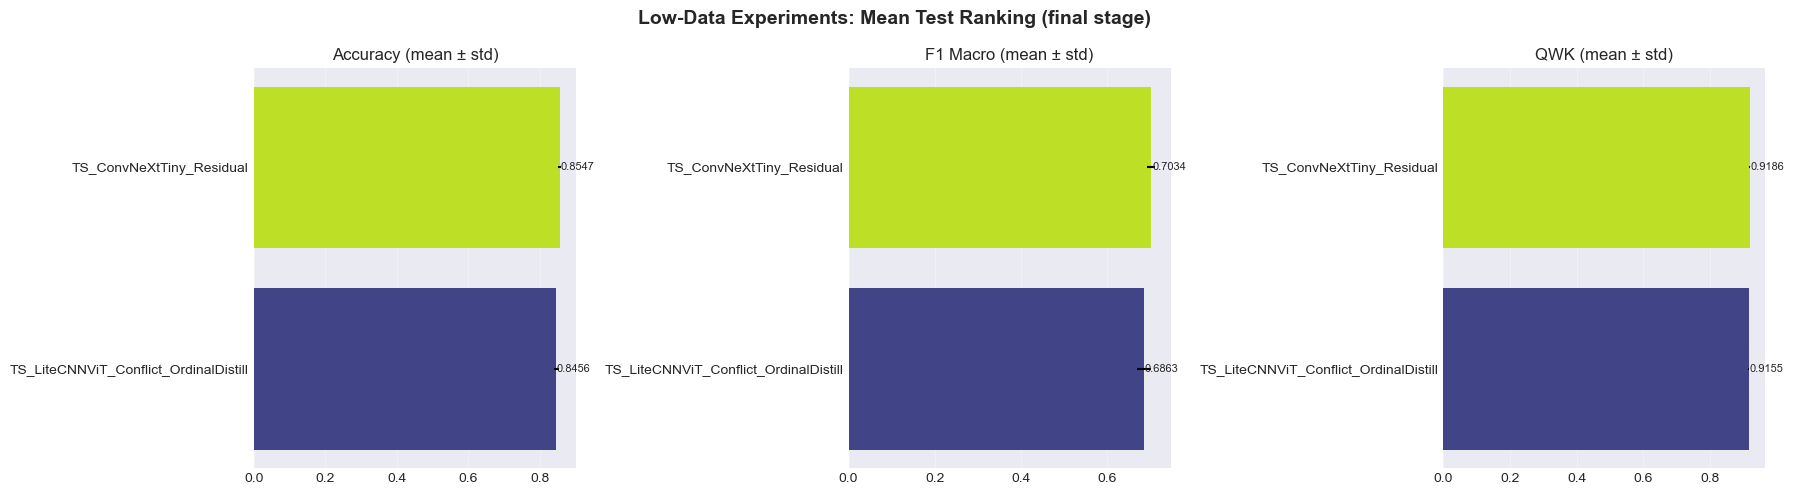

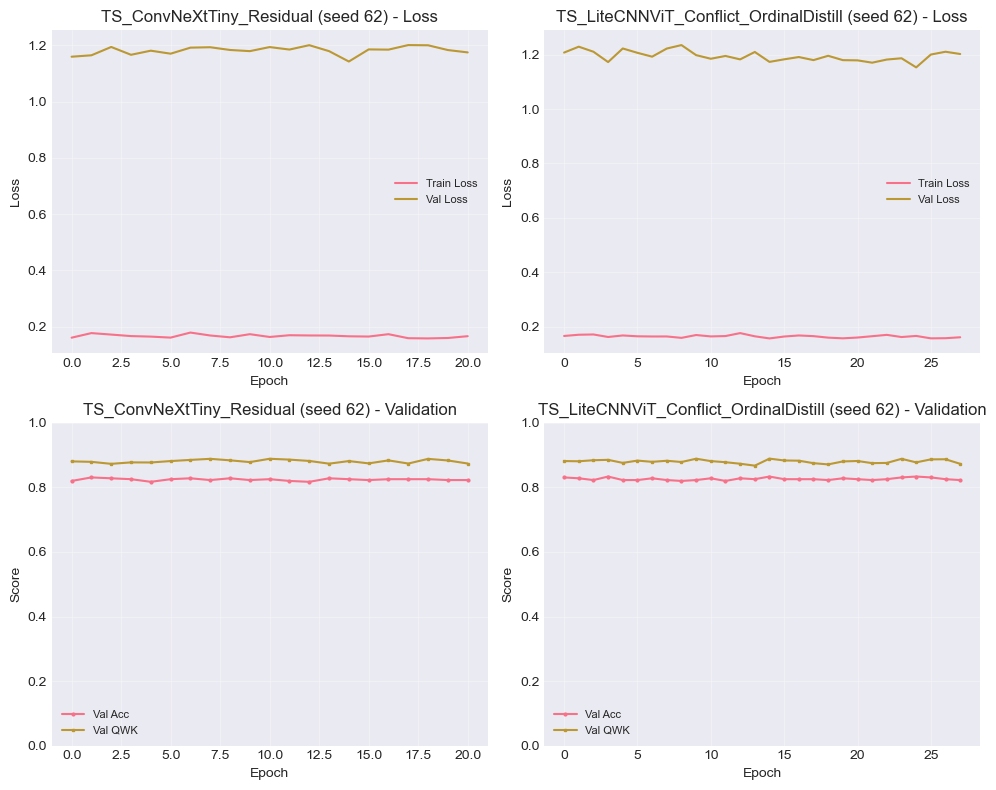

In [9]:
# 9) Plot: Ranking + Curves (Best Seed per Model)
rank_df = summary_df.copy()

if len(rank_df) == 0:
    raise RuntimeError('summary_df is empty. Run experiment loop first.')

plot_source_df = seed_results_df.copy()
stage_label = 'all'
if 'Stage' in plot_source_df.columns and (plot_source_df['Stage'] == 'final').any():
    plot_source_df = plot_source_df[plot_source_df['Stage'] == 'final'].copy()
    stage_label = 'final'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Low-Data Experiments: Mean Test Ranking ({stage_label} stage)', fontsize=14, fontweight='bold')

plot_specs = [
    ('Accuracy_mean', 'Accuracy_std', 'Accuracy'),
    ('F1_Macro_mean', 'F1_Macro_std', 'F1 Macro'),
    ('QWK_mean', 'QWK_std', 'QWK'),
]

for ax, (mcol, scol, title) in zip(axes, plot_specs):
    sdf = rank_df.sort_values(mcol, ascending=True)
    ax.barh(
        sdf['Model'],
        sdf[mcol],
        xerr=sdf[scol].fillna(0.0),
        color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sdf)))
    )
    ax.set_title(title + ' (mean ± std)')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(sdf[mcol]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(results_dir / '00_lowdata_ranking_mean_std.png', dpi=150, bbox_inches='tight')
plt.show()

best_seed_df = plot_source_df.sort_values('QWK', ascending=False).groupby('Model', as_index=False).first()
best_seed_map = {r['Model']: int(r['Seed']) for _, r in best_seed_df.iterrows()}

model_names = rank_df['Model'].tolist()
fig, axes = plt.subplots(2, len(model_names), figsize=(5 * len(model_names), 8), sharex=False)
if len(model_names) == 1:
    axes = np.array(axes).reshape(2, 1)

for i, mname in enumerate(model_names):
    sd = best_seed_map.get(mname, None)
    if sd is None:
        axes[0, i].axis('off')
        axes[1, i].axis('off')
        continue

    hp = results_dir / mname / f'seed_{sd}' / 'training_history.json'
    if hp.exists():
        with open(hp, 'r', encoding='utf-8') as f:
            h = json.load(f)

        axes[0, i].plot(h.get('train_loss', []), label='Train Loss')
        axes[0, i].plot(h.get('val_loss', []), label='Val Loss')
        axes[0, i].set_title(f'{mname} (seed {sd}) - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].grid(alpha=0.3)
        axes[0, i].legend(fontsize=8)

        axes[1, i].plot(h.get('val_acc', []), label='Val Acc', marker='o', markersize=2)
        axes[1, i].plot(h.get('val_qwk', []), label='Val QWK', marker='s', markersize=2)
        axes[1, i].set_title(f'{mname} (seed {sd}) - Validation')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Score')
        axes[1, i].set_ylim([0, 1])
        axes[1, i].grid(alpha=0.3)
        axes[1, i].legend(fontsize=8)
    else:
        axes[0, i].axis('off')
        axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(results_dir / '01_lowdata_loss_val_curves_bestseed.png', dpi=150, bbox_inches='tight')
plt.show()

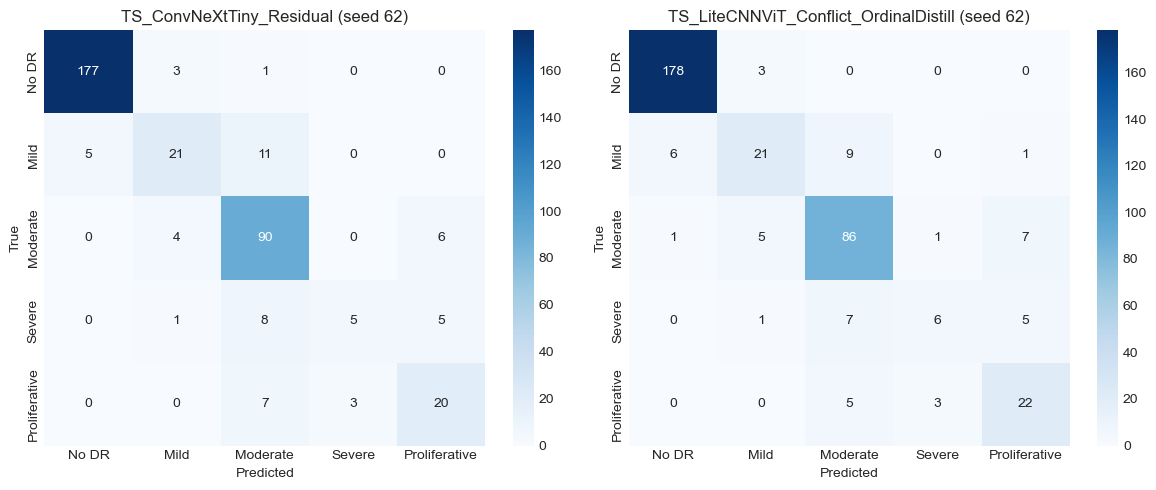

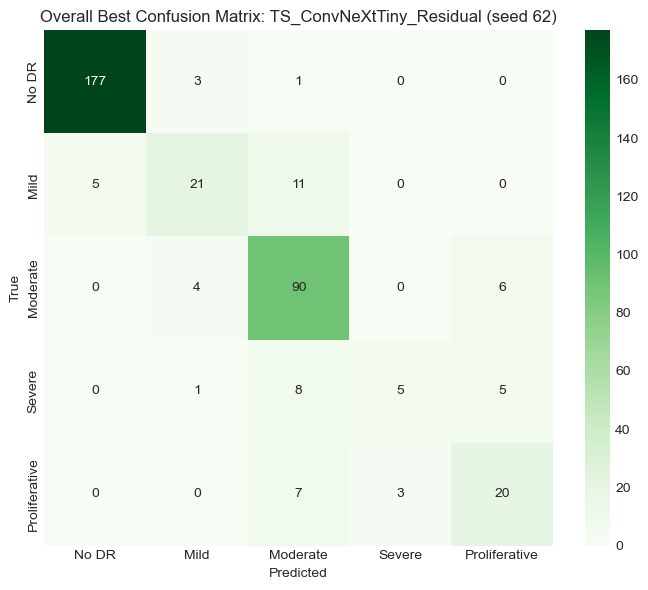

In [10]:
# 10) Plot: Confusion Matrices (best seed for each model + overall best)
plot_source_df = seed_results_df.copy()
if 'Stage' in plot_source_df.columns and (plot_source_df['Stage'] == 'final').any():
    plot_source_df = plot_source_df[plot_source_df['Stage'] == 'final'].copy()

best_seed_df = plot_source_df.sort_values('QWK', ascending=False).groupby('Model', as_index=False).first()
ok_models = best_seed_df['Model'].tolist()
labels = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

if len(ok_models) > 0:
    cols = min(3, len(ok_models))
    rows = int(np.ceil(len(ok_models) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(rows, cols)

    idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
            if idx < len(ok_models):
                mname = ok_models[idx]
                sd = int(best_seed_df.loc[best_seed_df['Model'] == mname, 'Seed'].values[0])
                mp = results_dir / mname / f'seed_{sd}' / 'test_metrics.json'
                if mp.exists():
                    with open(mp, 'r', encoding='utf-8') as f:
                        mr = json.load(f)
                    cm = np.array(mr['confusion_matrix'])
                    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=labels, yticklabels=labels)
                    ax.set_title(f'{mname} (seed {sd})')
                    ax.set_xlabel('Predicted')
                    ax.set_ylabel('True')
                else:
                    ax.axis('off')
            else:
                ax.axis('off')
            idx += 1

    plt.tight_layout()
    plt.savefig(results_dir / '02_lowdata_confusion_all_bestseed.png', dpi=150, bbox_inches='tight')
    plt.show()

    overall_best = plot_source_df.sort_values('QWK', ascending=False).iloc[0]
    best_model = overall_best['Model']
    best_seed = int(overall_best['Seed'])
    best_path = results_dir / best_model / f'seed_{best_seed}' / 'test_metrics.json'

    if best_path.exists():
        with open(best_path, 'r', encoding='utf-8') as f:
            br = json.load(f)
        cm_best = np.array(br['confusion_matrix'])
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
        plt.title(f'Overall Best Confusion Matrix: {best_model} (seed {best_seed})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(results_dir / '03_lowdata_confusion_overall_best.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('No confusion matrix data found.')

## Run Notes

Calistirma sirasi:
1. Hucre 1-7 bir kez calistir (import, setup, veri, metric, modeller, trainer)
2. Hucre 8 ile screening + top-2 final (3 seed) deney dongusunu baslat
3. Baglanti koparsa Hucre 8'i tekrar calistir (checkpoint/metric dosyalarindan devam eder)
4. Hucre 9 ile screening/final ozet tablolarini incele
5. Hucre 10 ile ranking ve egitim egrilerini uret
6. Hucre 11 ile confusion matrix gorsellerini uret
7. Hucre 14 opsiyoneldir (mimari gorsel)

Not: Tum metrikler test seti uzerinden raporlanir; veri bolunmesi orijinal 80-10-10'dur.

## Architecture Diagram Export (Paper-Ready)

Bu bolum en iyi anchored modelin tam mimari akisini (input -> branchler -> fusion -> output + loss) tek bir sekilde cizer ve PNG olarak kaydeder.

Saved: results\lowdata_hybrid_distill\04_best_model_layer_style_architecture.png


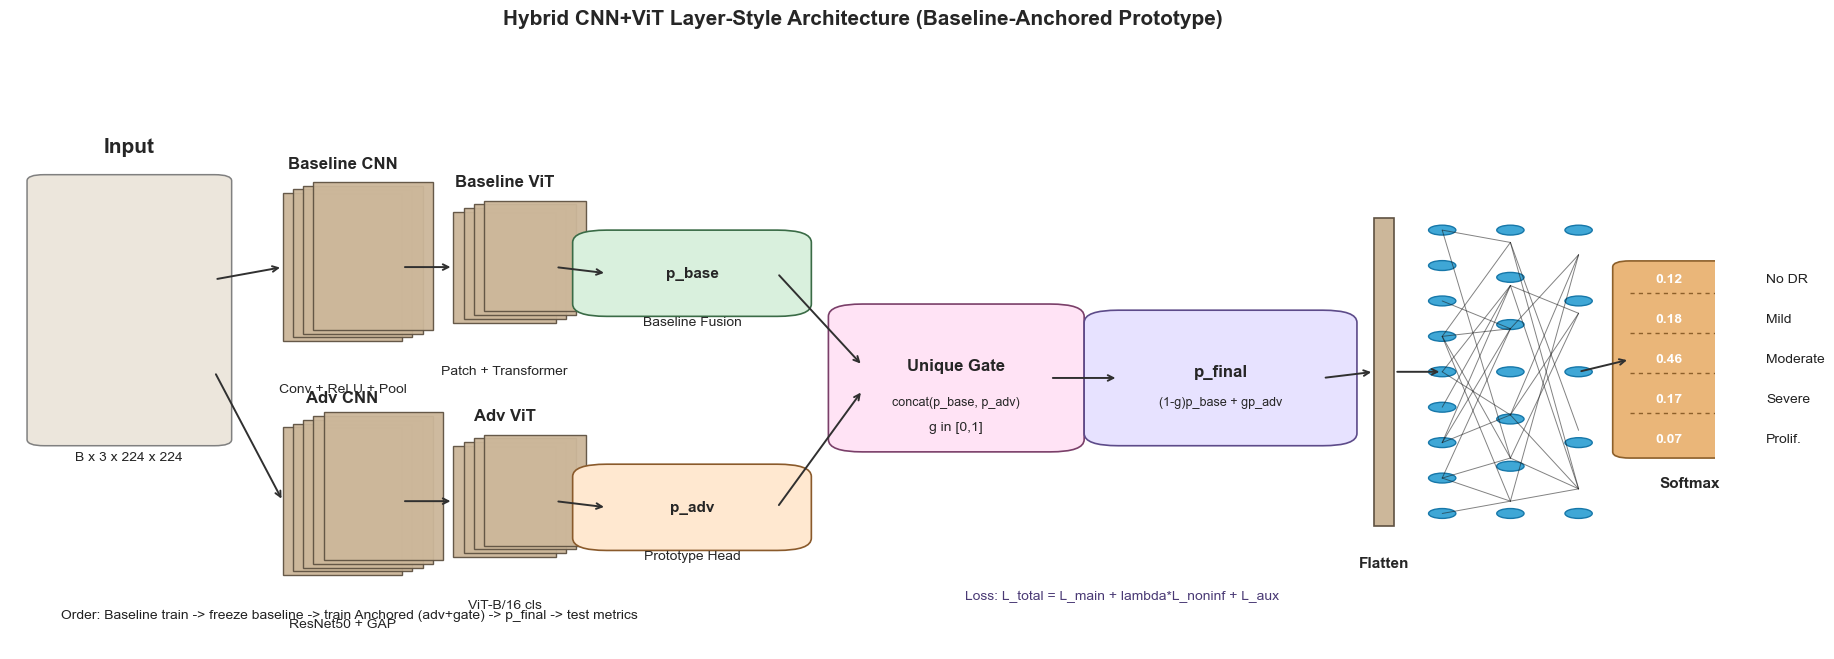

In [11]:
# 11) Draw and Save Layer-Style Architecture Diagram (CNN-like Visual)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle


def draw_stack(ax, x, y, w, h, n=5, dx=0.006, dy=0.006, fc="#d9c4a8", ec="#5c4d3a", label=""):
    for i in range(n):
        r = Rectangle((x + i * dx, y + i * dy), w, h, linewidth=1.0, edgecolor=ec, facecolor=fc, alpha=0.95)
        ax.add_patch(r)
    if label:
        ax.text(x + w * 0.5, y - 0.035, label, ha="center", va="top", fontsize=11, color="#222")


def draw_stage(ax, x, y, w, h, title, subtitle, n=5):
    draw_stack(ax, x, y, w, h, n=n, fc="#ccb79a", ec="#5f5242")
    ax.text(x + w * 0.5, y + h + 0.035, title, ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.text(x + w * 0.5, y - 0.07, subtitle, ha="center", va="top", fontsize=10)


def arrow(ax, x1, y1, x2, y2, ls="-"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.4, color="#303030", linestyle=ls))


def draw_prob_box(ax, x, y, w, h, probs, labels):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.01,rounding_size=0.01",
        linewidth=1.2, edgecolor="#8c5f2a", facecolor="#eab679"
    )
    ax.add_patch(box)

    ys = np.linspace(y + h - 0.02, y + 0.02, len(probs))
    for i, (p, lab, yy) in enumerate(zip(probs, labels, ys)):
        ax.text(x + 0.015, yy, f"{p:.2f}", va="center", ha="left", fontsize=10, color="white", fontweight="bold")
        ax.text(x + w + 0.01, yy, lab, va="center", ha="left", fontsize=10, color="#222")
        if i < len(probs) - 1:
            ax.plot([x, x + w], [yy - 0.022, yy - 0.022], color="#8c5f2a", lw=1.0, ls=(0, (3, 3)))

    ax.text(x + w * 0.5, y - 0.04, "Softmax", ha="center", va="top", fontsize=11, fontweight="bold")


fig, ax = plt.subplots(figsize=(22, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Input block (image placeholder style)
input_box = FancyBboxPatch((0.02, 0.34), 0.10, 0.42, boxstyle="round,pad=0.01", linewidth=1.1, edgecolor="#808080", facecolor="#ece6dc")
ax.add_patch(input_box)
ax.text(0.07, 0.80, "Input", ha="center", va="bottom", fontsize=15, fontweight="bold")
ax.text(0.07, 0.32, "B x 3 x 224 x 224", ha="center", va="top", fontsize=10)

# Baseline branch (upper lane)
draw_stage(ax, 0.16, 0.50, 0.07, 0.24, "Baseline CNN", "Conv + ReLU + Pool", n=4)
draw_stage(ax, 0.26, 0.53, 0.06, 0.18, "Baseline ViT", "Patch + Transformer", n=4)
base_fusion = FancyBboxPatch((0.35, 0.56), 0.10, 0.10, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#3a6b46", facecolor="#d9f0dd")
ax.add_patch(base_fusion)
ax.text(0.40, 0.61, "p_base", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.40, 0.54, "Baseline Fusion", ha="center", va="top", fontsize=10)

# Advanced branch (lower lane)
draw_stage(ax, 0.16, 0.12, 0.07, 0.24, "Adv CNN", "ResNet50 + GAP", n=5)
draw_stage(ax, 0.26, 0.15, 0.06, 0.18, "Adv ViT", "ViT-B/16 cls", n=4)
adv_fusion = FancyBboxPatch((0.35, 0.18), 0.10, 0.10, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#8a5a2b", facecolor="#ffe8d0")
ax.add_patch(adv_fusion)
ax.text(0.40, 0.23, "p_adv", ha="center", va="center", fontsize=11, fontweight="bold")
ax.text(0.40, 0.16, "Prototype Head", ha="center", va="top", fontsize=10)

# Gate and final fusion
gate_box = FancyBboxPatch((0.50, 0.34), 0.11, 0.20, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#7a3f69", facecolor="#ffe3f5")
ax.add_patch(gate_box)
ax.text(0.555, 0.46, "Unique Gate", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(0.555, 0.40, "concat(p_base, p_adv)", ha="center", va="center", fontsize=9)
ax.text(0.555, 0.36, "g in [0,1]", ha="center", va="center", fontsize=10)

mix_box = FancyBboxPatch((0.65, 0.35), 0.12, 0.18, boxstyle="round,pad=0.02", linewidth=1.2, edgecolor="#5d4b8a", facecolor="#e7e2ff")
ax.add_patch(mix_box)
ax.text(0.71, 0.45, "p_final", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(0.71, 0.40, "(1-g)p_base + gp_adv", ha="center", va="center", fontsize=9)

# Flatten + dense style
flat = Rectangle((0.80, 0.20), 0.012, 0.50, linewidth=1.2, edgecolor="#5f5242", facecolor="#ccb79a")
ax.add_patch(flat)
ax.text(0.806, 0.15, "Flatten", ha="center", va="top", fontsize=11, fontweight="bold")

# Dense layers (node style)
dense_x = [0.84, 0.88, 0.92]
dense_n = [9, 7, 5]
for x, n in zip(dense_x, dense_n):
    ys = np.linspace(0.22, 0.68, n)
    for y in ys:
        ax.add_patch(Circle((x, y), 0.008, edgecolor="#1677a9", facecolor="#3fa7d6", linewidth=1.0))

# Simple connection lines between dense layers
for y1 in np.linspace(0.22, 0.68, dense_n[0]):
    for y2 in np.linspace(0.24, 0.66, dense_n[1]):
        if np.random.rand() < 0.28:
            ax.plot([dense_x[0], dense_x[1]], [y1, y2], color="#1b1b1b", lw=0.7, alpha=0.55)
for y1 in np.linspace(0.24, 0.66, dense_n[1]):
    for y2 in np.linspace(0.26, 0.64, dense_n[2]):
        if np.random.rand() < 0.35:
            ax.plot([dense_x[1], dense_x[2]], [y1, y2], color="#1b1b1b", lw=0.7, alpha=0.55)

# Output probability box
draw_prob_box(
    ax, 0.95, 0.32, 0.07, 0.30,
    probs=[0.12, 0.18, 0.46, 0.17, 0.07],
    labels=["No DR", "Mild", "Moderate", "Severe", "Prolif."]
)

# Arrows for processing order
arrow(ax, 0.12, 0.60, 0.16, 0.62)
arrow(ax, 0.12, 0.45, 0.16, 0.24)
arrow(ax, 0.23, 0.62, 0.26, 0.62)
arrow(ax, 0.23, 0.24, 0.26, 0.24)
arrow(ax, 0.32, 0.62, 0.35, 0.61)
arrow(ax, 0.32, 0.24, 0.35, 0.23)
arrow(ax, 0.45, 0.61, 0.50, 0.46)
arrow(ax, 0.45, 0.23, 0.50, 0.42)
arrow(ax, 0.61, 0.44, 0.65, 0.44)
arrow(ax, 0.77, 0.44, 0.80, 0.45)
arrow(ax, 0.812, 0.45, 0.84, 0.45)
arrow(ax, 0.92, 0.45, 0.95, 0.47)

# Training notes
ax.text(0.03, 0.05, "Order: Baseline train -> freeze baseline -> train Anchored (adv+gate) -> p_final -> test metrics", fontsize=10, color="#222")
ax.text(0.56, 0.08, "Loss: L_total = L_main + lambda*L_noninf + L_aux", fontsize=10, color="#4a3a75")

plt.title("Hybrid CNN+ViT Layer-Style Architecture (Baseline-Anchored Prototype)", fontsize=15, fontweight="bold")

arch_path = results_dir / "04_best_model_layer_style_architecture.png"
plt.savefig(arch_path, dpi=240, bbox_inches="tight")
print("Saved:", arch_path)
plt.show()